In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt





In [2]:
df=pd.read_csv('binary_classification_train.csv')
df.head(15)

,ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Class
0,1,-36.963099,-15.014703,87.100435,101.523360,82.106571,-10.956180,0.592326,-51.919028,-90.650434,...,-81.183744,13.101921,18.051450,-40.606288,-39.697053,-13.870802,173.722987,-17.349169,-82.550844,0
1,2,-43.715674,18.847116,89.543406,-71.319314,35.597052,126.358570,-29.837495,-40.473764,-94.079238,...,-37.848260,7.457352,-77.420742,53.773718,-100.124294,9.870650,11.592519,-106.123605,-92.796421,1
2,3,-30.737550,-63.729643,106.081332,81.773948,112.769976,-12.425351,-29.913286,-41.771200,16.424511,...,-106.610289,5.930143,-30.177083,-138.969234,-56.054914,-12.790661,164.832498,-37.412902,-85.441150,0
3,4,-27.674757,-118.869495,135.605213,99.130189,50.947548,-63.704785,-7.353057,-58.140229,-80.209027,...,-149.056417,3.893419,-74.100869,-47.659832,-48.209817,-36.264323,59.001922,-59.064134,-78.538639,0
4,5,-28.654141,-77.746597,85.215365,50.374774,79.763207,-32.703048,-28.152031,-63.994794,-153.566789,...,-102.731465,11.160205,-13.395073,9.416237,2.649524,-43.578704,52.261888,-66.081738,-80.325110,0
5,6,-38.117646,-33.507201,136.486830,110.598904,81.473220,-11.071980,-11.951786,-45.813208,-119.127127,...,1.500816,2.695457,1.396752,-92.554534,-12.519282,-13.926158,93.605695,-66.760545,-81.819177,0
6,7,-32.710837,-104.556238,99.556202,95.745037,122.140531,-59.949488,-26.897662,-57.708221,-176.379515,...,-97.535000,14.698240,-75.975937,10.561465,-92.801302,-16.242821,238.975354,-16.785631,-84.975001,0
7,8,-30.299229,-115.496618,107.734218,39.097323,58.528459,52.726004,-27.217253,-41.187358,-82.751154,...,-82.413299,5.861742,-293.635505,252.984181,-94.177349,-39.441920,183.493337,-36.680057,-79.694120,0
8,9,-42.547561,-144.806414,56.864835,-95.112571,55.815012,30.994533,10.739369,-53.023606,-80.888967,...,-43.431448,9.068072,-135.121926,341.669737,27.339864,-102.492365,119.226366,-12.871705,-82.028582,0
9,10,-37.368474,-78.407211,98.505033,118.360329,99.013203,57.520589,-8.262817,-50.428133,-117.502069,...,-68.698371,12.566891,125.967323,-31.805446,-7.892274,7.885237,144.233356,-13.811959,-82.958289,0


In [3]:
X_train=df.iloc[:,1:-1].to_numpy()
print(X_train)

[[ -36.96309934  -15.01470294   87.10043472 ...  173.72298705
   -17.34916949  -82.55084389]
 [ -43.71567402   18.8471157    89.54340644 ...   11.59251925
  -106.12360525  -92.79642051]
 [ -30.73755019  -63.72964268  106.08133168 ...  164.83249783
   -37.41290151  -85.44115039]
 ...
 [ -35.345541    -80.69036019   94.40284293 ...  135.92923004
   -48.4083528   -75.40615407]
 [ -39.59406722  -63.80427731   52.27065677 ...  208.53435295
   -38.51438167  -85.69418917]
 [ -32.70246498 -111.47849646  109.34139873 ...  126.45446899
   -38.14487487  -86.07439614]]


In [4]:
y_train=df.iloc[:,-1].to_numpy()
print(y_train)


[0 1 0 ... 0 0 1]


In [5]:
X_train_norm=X_train.copy()
mu=np.mean(X_train_norm,axis=0)
sigma=np.std(X_train_norm,axis=0)
X_train_norm=(X_train_norm-mu)/sigma
print(X_train_norm)



[[-9.08190768e-01  1.57967414e+00 -1.17236266e-01 ...  8.63614833e-01
   1.21308564e+00  2.60867300e-01]
 [-2.35013733e+00  2.32275655e+00 -5.45947826e-02 ... -1.39951036e+00
  -1.70459490e+00 -2.02244642e+00]
 [ 4.21214627e-01  5.10646659e-01  3.69462590e-01 ...  7.39515456e-01
   5.53666517e-01 -3.83262037e-01]
 ...
 [-5.62776936e-01  1.38451328e-01  7.00085059e-02 ...  3.36064368e-01
   1.92287545e-01  1.85312207e+00]
 [-1.47000834e+00  5.09008835e-01 -1.01032436e+00 ...  1.34953509e+00
   5.17465022e-01 -4.39653875e-01]
 [ 1.62620901e-03 -5.37180499e-01  4.53055631e-01 ...  2.03809334e-01
   5.29609316e-01 -5.24386227e-01]]


In [6]:
m=X_train_norm.shape[0]
print(m)

48000


In [7]:
J_hist=[]
w=np.zeros_like(df.columns[1:-1])
b=np.mean(y_train)
for i in range(1000):
    if i%100==0:
        J_hist.append((np.dot(y_train,np.log(1+np.exp(-(np.dot(X_train_norm,w)+b).astype(float))))-np.dot(1-y_train,np.log(1-1/(1+np.exp(-(np.dot(X_train_norm,w)+b).astype(float))))))/m)
        print(J_hist[-1])
    dj_dw=np.dot(X_train_norm.T,1/(1+np.exp(-(np.dot(X_train_norm,w)+b).astype(float)))-y_train)/m
    dj_db=np.dot(np.ones_like(X_train_norm[:,0]),1/(1+np.exp(-(np.dot(X_train_norm,w)+b).astype(float)))-y_train)/m
    w-=10*dj_dw
    b-=10*dj_db


0.7635868056760664
0.2466672197299264
0.24666721972992642
0.24666721972992642
0.24666721972992642
0.24666721972992642
0.24666721972992642
0.24666721972992642
0.24666721972992642
0.24666721972992642


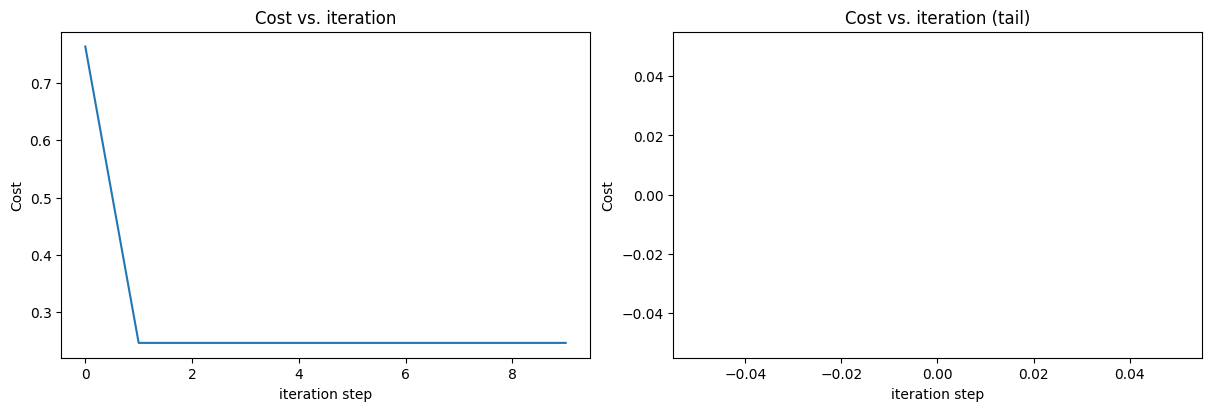

In [8]:
fig,(ax1,ax2)=plt.subplots(1,2,constrained_layout=True,figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])),J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

In [9]:
df=pd.read_csv('binary_classification_test.csv')
print(df)

          ID  Feature_1   Feature_2   Feature_3  Feature_4   Feature_5  \
0          1 -21.263636 -101.510764   70.115563 -67.257828   60.603386   
1          2 -28.646489 -104.090028  124.098974 -45.906780   85.691869   
2          3 -34.084427 -149.471464  131.883193  96.372918   41.865528   
3          4 -38.905587 -126.038930   86.480118 -76.173919   98.722116   
4          5 -41.041415 -124.302646   89.549410 -98.980090   72.425692   
...      ...        ...         ...         ...        ...         ...   
11995  11996 -24.270292  -40.953059  126.403165 -85.023186   73.873895   
11996  11997 -30.474886 -201.124891   79.824920 -96.541722   77.483155   
11997  11998 -24.547995 -152.072592  132.767918 -27.689569  141.583374   
11998  11999 -29.200068 -100.303304  115.709923 -91.765981  108.346710   
11999  12000 -25.239428 -188.996751   87.775963 -58.966752   89.806261   

        Feature_6  Feature_7  Feature_8   Feature_9  ...  Feature_11  \
0      -14.047965 -20.077225 -39.171738

In [10]:
X_test=df.iloc[:,1:].to_numpy()
print(X_test)

[[ -21.26363576 -101.51076439   70.11556349 ...  136.88072759
   -53.74652746  -88.62431164]
 [ -28.64648942 -104.09002777  124.09897384 ...  155.04005059
   -43.39047591  -85.58479057]
 [ -34.08442676 -149.47146391  131.88319263 ...  201.92991029
   -40.22577214  -86.23567733]
 ...
 [ -24.54799465 -152.07259248  132.76791814 ...  148.10618381
   -80.19449353  -89.79112231]
 [ -29.20006765 -100.30330433  115.70992256 ...  180.81790728
   -36.34370299  -85.99400505]
 [ -25.23942763 -188.99675094   87.77596258 ...  175.62274141
   -19.16044345  -81.53031155]]


In [11]:
X_test_norm=X_test.copy()
X_test_norm=(X_test_norm-mu)/sigma
print(X_test_norm)

[[ 2.44427679 -0.31844309 -0.55275401 ...  0.34934601  0.0168419
  -1.09265654]
 [ 0.86774029 -0.37504387  0.83146214 ...  0.60282595  0.35720621
  -0.41527347]
 [-0.29347827 -1.37091911  1.03106126 ...  1.25734588  0.46121808
  -0.56032911]
 ...
 [ 1.74293394 -1.42799971  1.05374696 ...  0.50603841 -0.8524029
  -1.3526902 ]
 [ 0.74952905 -0.29194593  0.6163542  ...  0.96265046  0.58880704
  -0.50647039]
 [ 1.59528516 -2.23828379 -0.09991471 ...  0.89013287  1.1535559
   0.4883016 ]]


In [12]:
z=np.dot(X_test_norm,w)+b
y_test=np.round(1/(1+np.exp(-z.astype(float))))
print(y_test)

[0. 0. 0. ... 0. 1. 0.]


In [13]:
print(y_train)

[0 1 0 ... 0 0 1]


In [14]:
z=np.dot(X_train_norm,w)+b
y_pred=np.round(1/(1+np.exp(-z.astype(float))))
print(y_pred)

[0. 1. 0. ... 0. 0. 1.]


In [15]:
true_positives=np.sum((y_train==1) & (y_pred==1))
false_positives=np.sum((y_train==0) & (y_pred==1))
false_negatives=np.sum((y_train== 1) & (y_pred==0))

precision=true_positives/(true_positives+false_positives) if (true_positives+false_positives)>0 else 0
recall=true_positives/(true_positives+false_negatives) if (true_positives+false_negatives)>0 else 0

f1_score=2*precision*recall/(precision+recall) if (precision+recall)>0 else 0

print(f1_score)

0.893748514380794


In [16]:
print(np.sum(y_train==y_pred)/y_train.shape[0])

0.9348125
